In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rcParams['font.family'] = 'Malgun Gothic' # For Windows
plt.rcParams["font.family"] = "AppleGothic"   # Mac
%matplotlib inline

In [72]:
df=pd.read_csv("../공유/final_cleaned_airbnb.csv")

In [73]:
display(df.shape)
display(df.head())

(19861, 65)

,name,host_since,host_response_time,host_acceptance_rate,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,...,legal_flag,price_q,occupancy_rate,log_reviews,recent_activity,operating_days,log_revenue,neighbourhood_top10,host_since_dt,property_regulation_type
0,Lg Rm in Historic Prospect Heights,2009-12-11,no_reponse_data,no_request,Prospect Heights,Brooklyn,Private room in rental unit,Private room,1,1.0,...,Legal,Q3,0.000000,2.302585,0,5564.0,0.000000,Other,2009-12-11,Residential_long_term
1,"1 Bedroom & your own Bathroom, Elevator Apartment",2010-07-04,no_reponse_data,100%,East Harlem,Manhattan,Private room in condo,Private room,2,1.0,...,Legal,Q1,0.000000,4.634729,0,5632.0,0.000000,Other,2010-07-04,Residential_long_term
2,Luxury Brownstone in Boerum Hill,2010-07-13,within a few hours,40%,Boerum Hill,Brooklyn,Private room in home,Private room,2,2.5,...,Legal,Q4,0.000000,3.784190,0,4988.0,0.000000,Other,2010-07-13,Residential_short_term
3,“Work-from-home” from OUR home.,2010-07-16,within an hour,100%,Williamsburg,Brooklyn,Private room in rental unit,Private room,2,1.0,...,Legal,Q2,0.421918,5.616771,0,5695.0,9.904537,Williamsburg,2010-07-16,Residential_short_term
4,1 br in a 2 br apt (Midtown West),2010-07-17,no_reponse_data,no_request,Hell's Kitchen,Manhattan,Private room in rental unit,Private room,2,0.0,...,Legal,Q2,0.000000,3.806662,0,5666.0,0.000000,Hell's Kitchen,2010-07-17,Residential_long_term


## 경쟁과 포지셔닝 / 운영 요소의 영향
1️⃣ 경쟁과 포지셔닝 - "레드오션 vs 블루오션"
- **Scatter Plot (공급량 vs 평균 매출)**
- X축: 동네별 매물 수(공급), Y축: 동네별 평균 매출(수익)

**분석**

우상향: 수익도 좋고 공급도 많은 인기 지역 (레드오션)

좌상향: 공급은 적은데 수익은 높은 꿀지역 (**블루오션**)

- 우하향: 공급만 많고 수익은 낮은 위험 지역 (**치킨게임**)
---------------------------------------------------------
필요 변수
(큰 지역)'neighbourhood_group_cleansed'
( 동네 )'neighbourhood_cleansed'
-> 우선 큰지역부터 보기.
estimated_revenue_l365d 추정 최근 연간매출

x 축 (동네별) -> 'neighbourhood_group_cleansed' 매물수 확인
y 축 (동네별) -> 평균매출 데이터 없음.(예상 연매출)    !! 평균매출. 하루 숙박 평균매출 vs 연평균매출 뭐가 필요한가. -> 상식적으로 연매출 추천이 적합.

지역별로 집계 연평균매출

지역별 평균매출 어디가 높은가.
근데
분석주제다시 돌아보기
"어디에 어떤 숙소를 내놓아야 수익이 높은가"
그럼 room_typerhk 지역구로도 봐볼까.
지역구별 + 어떤 숙소 + 매출

또는 
"어떤 숙소에 어떤 옵션이 있으면 매출이 높은가?"
지역+숙소+옵션+매출

또는 
"어떤 숙소가 서비스를 잘 하면 매출이 높은가?"
지역+숙소+옵션+서비스+매출

-> 운영 요소 까지 합해서 같이 가능.
-> 옵션아니 서비스 같은 경우는 상관관계보다 인과관계로써의 설명이 더 적합함.


In [74]:
df['neighbourhood_group_cleansed'].value_counts()

neighbourhood_group_cleansed
Manhattan        9125
Brooklyn         6585
Queens           3054
Bronx             814
Staten Island     283
Name: count, dtype: int64

In [78]:
df['estimated_revenue_l365d'].describe()

count     19861.000000
mean       8596.544988
std       16205.096572
min           0.000000
25%           0.000000
50%           0.000000
75%       12240.000000
max      374524.000000
Name: estimated_revenue_l365d, dtype: float64

In [75]:
df['price'].describe()

count    19861.000000
mean       205.923216
std        423.890576
min          7.000000
25%         81.000000
50%        134.000000
75%        230.000000
max      20000.000000
Name: price, dtype: float64

In [82]:
#점유율 = 숙소가 1년 중 얼마나 예약되어 있었는가?
df['occupancy_rate'] = df['estimated_occupancy_l365d'] / 365
df['occupancy_rate'].describe()
#에어비앤비 평균 점유율은 약 17%

count    19861.000000
mean         0.168030
std          0.245398
min          0.000000
25%          0.000000
50%          0.000000
75%          0.328767
max          0.698630
Name: occupancy_rate, dtype: float64

In [116]:
df_summary=df.groupby(['neighbourhood_group_cleansed','property_regulation_type']).agg(
    listing_count=('price','count'),
    occupancy_mean=('occupancy_rate','mean'),
    occupancy_meian=('occupancy_rate','median'),
    price_median=('price','median'),
    revenue_median=('estimated_revenue_l365d','median')
).reset_index()

In [ ]:
# log -> 목표는 비지니스 의사결정이다. log으로 하면 해석의 복잡성 -> 분포 안정화, 머신러닝과 통게에 더 유용하다.
# 로그 변환은 분포만 안정화 하는 것. 극단값을 제외하고 나머지를 본다면 다른 숙소들의 차이가 크게 안보일 가능성도 있음 ->실제가격 왜곡
# 로그 근거요약
# 로그는 분포안정화 목적인 것 뿐, 금액해석에 왜곡+ 시장장규모 분석에는 실제 값이 필요하므로 쓰지 않는다. 모델링 단계가 가장 적합하다.
# 왜냐하면 로그로 변환했다고 해서 실제 값이 완화 되어 보이는 것뿐 실제 가격이 제거되거나 바뀌는 것은 아니기 때문이다. 
# mean -> 극단값이 존재, 평균 왜곡  
# -> 그러나 시장 규모로 볼 수 있음 즉. 시장에 흐르는 돈이 이정도나 된다. 그러나, 럭셔리 숙소의 매물이 적어서 올라간 값이라면, 시장규모를 대표할 수 없다.
# median -> 럭셔리 숙소를 제외한 일반적인 숙소가 벌어들이는 현실적인 매출 과 안정적인 시장 흐름/매출 (최종)

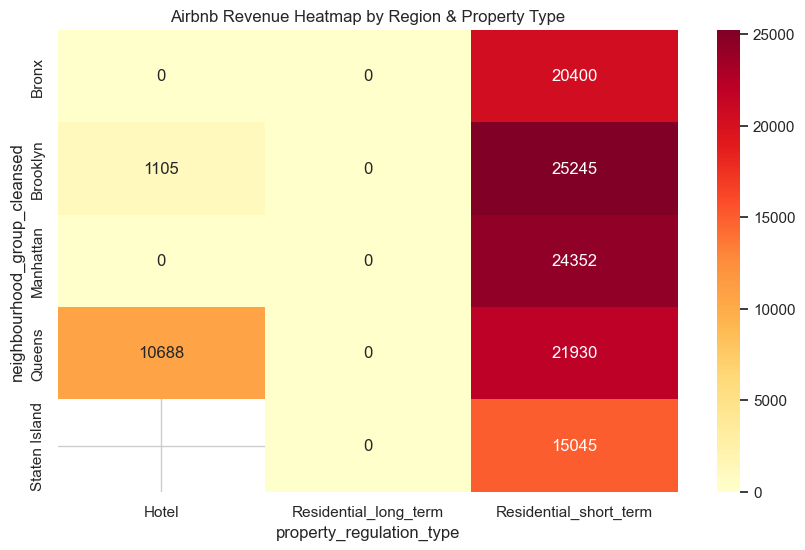

In [ ]:
# 어떤지역 어떤 숙소타입이 수익이 높고 경쟁이 심할지. ---> brooklyn 지역의 단기임대가 점유율 이 높다.
import seaborn as sns
import matplotlib.pyplot as plt

# pivot 테이블 만들기
pivot = df_summary.pivot_table(
    index='neighbourhood_group_cleansed', 
    columns='property_regulation_type', 
    values='revenue_median'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd") # 밝을수록 수익 높음
plt.title('Airbnb Revenue Heatmap by Region & Property Type')
plt.show()

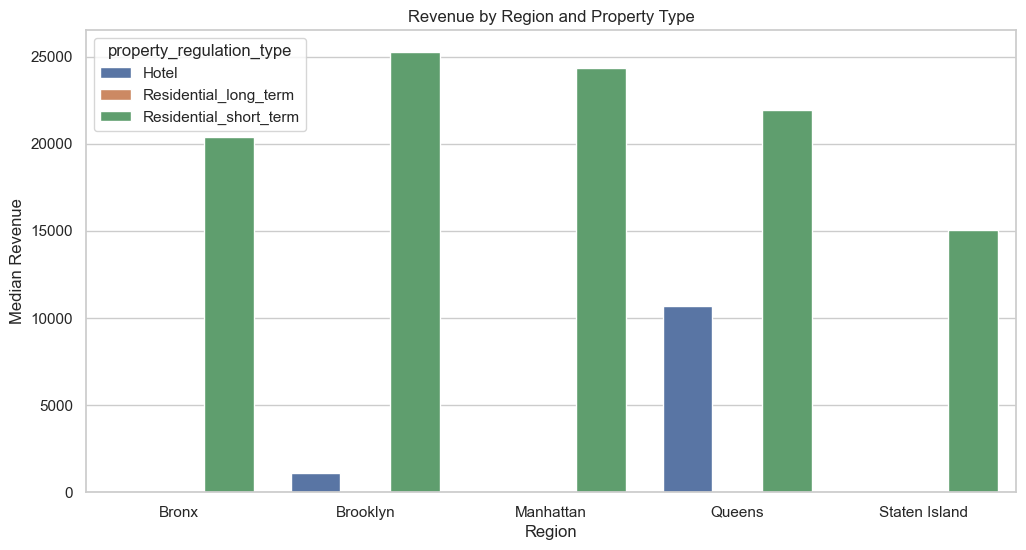

In [ ]:
# 경쟁 강도 대비 수익 비교
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_summary, 
    x='neighbourhood_group_cleansed', 
    y='revenue_median', 
    hue='property_regulation_type'
)
plt.title('Revenue by Region and Property Type')
plt.ylabel('Median Revenue')
plt.xlabel('Region')
plt.show()

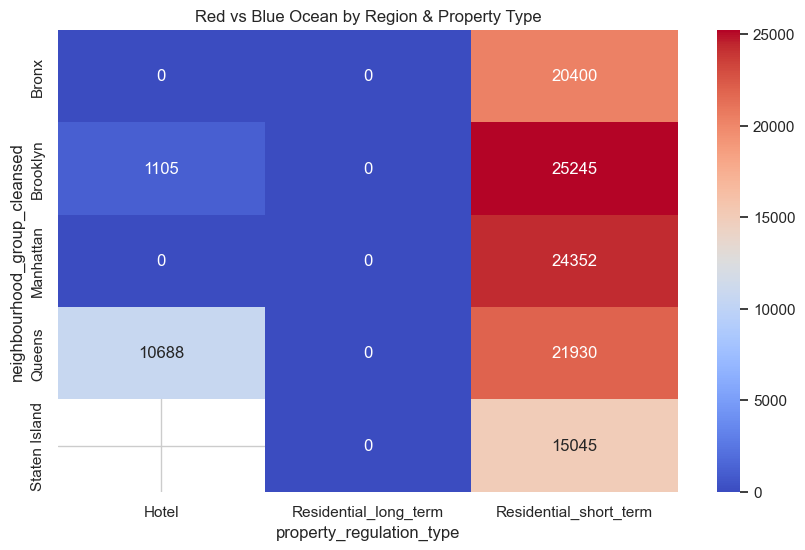

In [ ]:
# 레드 경쟁심함 레드/블루오션
df_summary['ocean'] = df_summary['listing_count'].apply(lambda x: 'Red' if x>500 else 'Blue')

pivot_ocean = df_summary.pivot_table(
    index='neighbourhood_group_cleansed',
    columns='property_regulation_type',
    values='revenue_median'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot_ocean, annot=True, fmt=".0f", cmap="coolwarm")
plt.title('Red vs Blue Ocean by Region & Property Type')
plt.show()

##
어느지역이 돈이 되냐?
호텔 주거용중 어던게 더 잘 차냐?
가격이 높은데 잘 차는 지역이 어디냐

In [103]:
df['listing_coun']=df['price'].count()

In [ ]:
#Bronx->814개
#Brooklyn->6585
#Manhattan->9125
#q ->3054
#S ->283

In [112]:
# 지역구와 점유율
df.groupby('neighbourhood_group_cleansed')['occupancy_rate'].agg(['mean','median','count'])


,mean,median,count
neighbourhood_group_cleansed,,,
Bronx,0.161782,0.000000,814
Brooklyn,0.186590,0.000000,6585
Manhattan,0.146151,0.000000,9125
Queens,0.192554,0.000000,3054
Staten Island,0.194966,0.035616,283


# 해석
1. 절반 이상 숙소 예약 없음 : 단순 숙소 수가 많아도 실제 점유율과 매출을 낮을 수 있다.
2. 점유율 평균 vs 중앙값 차이
차이의 이유 => 일부 인기 숙소에 예약이 몰려있음.
그래서  평균으로만 보면 '시장점유율이 높다'고 착각 할수있어서 중앙값도 확인 필수임
3. 지역별 점유율 순위
평균 기준: Queens+Staten island > Brooklyn > Bronx > manhatten
중앙값 기준: Staten Island에 소규모 숙소가 예약 몰림, Manhatten은 대규모이지만 절반이상이 비활성 숙소일 가능성

4. brooklyn vs manhatten 
b = 평균 0.187 중앙값 0 -> 절반이상 예약없음. 인기숙소 꽤나 있음
m = 평균 0.14 중앙값 0  -> 절반이상 예약없음, 인기숙소 몰려도 수가 적어서 평균 낮음
-> 시장 대비 실제 점유율은 B 가 약간 더 높다. , M은 극단값 몇개가 평균 올림

5 점유율 기반 지역별 운영전략
중앙값 0 대부분 숙소가 비활성이 되어있고,
평균> 중앙값   일부 숙소가 극단적으로 예약됨
전략:
1. 인기숙소가 몰린 지역이나 옵션 확인
2. 신규호스트는 중앙값보다 높은 점유율 지역이나 트랙에 초점
3. 운영요소(가격,서비스,옵션)을 결합해 극단값을 노리는 것이 효과적이다. (기존호스트)

신규 호스트 기준: Staten Island, Queens, Brooklyn → 인기 숙소 선택 시 수익 가능성 높음

Manhattan과 Bronx → 평균은 낮지 않지만 극단값 몇 개만 올려 평균 높음, 대부분 숙소 비활성 → 신규 진입에는 위험

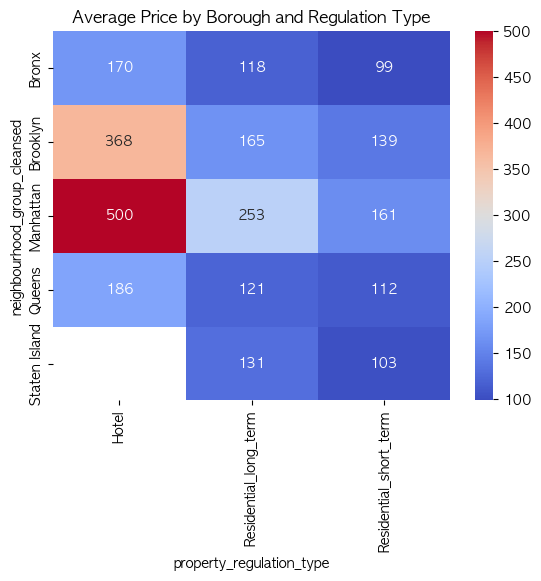

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = df.groupby(
    ['neighbourhood_group_cleansed','property_regulation_type']
)['price'].mean().unstack()

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Average Price by Borough and Regulation Type")
plt.show()